In [1]:
## 0. load packages
import os, sys
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import matplotlib.ticker as ticker
import matplotlib.colors as colors
import seaborn as sns
from scipy.stats import norm
from datetime import datetime

os.chdir('/h/u145/liuxinrui/CROP/')
sys.path.insert(0, '/h/u145/liuxinrui/CROP/')

impact_models =  ['CYGMA1p74', 'EPIC-IIASA', 'ISAM', 'LDNDC', 'LPJmL', 'PEPIC', 'PROMET', 'SIMPLACE-LINTUL5']
spcs = ['mai', 'ri1', 'ri2', 'soy', 'swh', 'wwh']
spcs4 = ['mai', 'ric', 'soy', 'whe']
crop_mapping = {'Maize': ['mai'], 'Rice':['ri1', 'ri2', 'ric'], 'Soybean':['soy'], 'Wheat':['swh', 'wwh', 'whe']}

valid = xr.load_dataarray('/h/u145/liuxinrui/Data/ISIMIP3b/RC/valid_coords.nc')
extrema_mask = xr.load_dataarray('input_data/regions/extrema_mask.nc')
map_mask = xr.load_dataset('input_data/regions/region_mask_0p5deg.nc')['frac_reg']

mod_colors = ['#008080', '#FF7F50', '#9370DB', '#DAA520', '#228B22', '#87CEEB',  '#CC5500',  '#708090']
spc_colors = ["#E6A211", "#6FE235", "#10A843", "#F4F465", "#E25793", "#880E9B"]
scen_colors = ["#1C69C2", '#A6D854', '#66C2A5', '#FC8D62']
mod_markers = ['o', 's', 'D', '^', 'v', 'p', 'P', 'X']

## dry weight conversion factor
## https://doi.org/10.5194/essd-17-369-2025, Table 2
dw = xr.DataArray([0.82, 0.87, 0.85, 0.86], coords={'spc_crop': ['mai', 'ric', 'soy', 'whe']}, dims=['spc_crop'])

nMC = 1000
out_dir = 'results/Mar/ISIMIP3b/'

## 1. Run model

### 1.1. Parameters

In [14]:
## 1.1. load parameters

print('+'*50)
current_datetime = datetime.now()
print(f'Current date and time: {current_datetime}')
print('+'*50, '\n')

Par = xr.load_dataset(f'results/Mar/Par.nc')

++++++++++++++++++++++++++++++++++++++++++++++++++
Current date and time: 2026-03-24 15:15:51.709393
++++++++++++++++++++++++++++++++++++++++++++++++++ 



### 1.2 Drivers

In [ ]:
## 1.2. load drivers

print('+'*50)
current_datetime = datetime.now()
print(f'Current date and time: {current_datetime}')
print('+'*50, '\n')

from core.Dri_crop import load_Nfertl_scen, load_Ndep_scen
soc = '2015soc'
scenario = 'ssp585'
if scenario in ['ssp126', 'ssp370', 'ssp585']: ind0, ind1 = 2015, 2100
if scenario == 'historical': ind0, ind1 = 1850, 2014

For_clim_hist = (
    xr.load_dataset('./input_data/observations/land-climate__ISIMIP3b_sub-national.nc')
    .sel(scen='historical', drop=True).dropna(dim='year', how='all')
)
For_co2_hist = (
    xr.load_dataset('./input_data/observations/concentrations__ISIMIP3b.nc')
    .sel(scen='historical', drop=True).dropna(dim='year', how='all')
)

if scenario in ['ssp126', 'ssp370', 'ssp585']:
    For_clim_scen = (
        xr.load_dataset('./input_data/observations/land-climate__ISIMIP3b_sub-national.nc')
        .sel(scen=scenario, drop=True).dropna(dim='year', how='all')
    )
    For_clim_scen = For_clim_scen.combine_first(For_clim_hist)
    For_co2_scen = (
        xr.load_dataset('./input_data/observations/concentrations__ISIMIP3b.nc')
        .sel(scen=scenario, drop=True).dropna(dim='year', how='all')
    )
    For_co2_scen = For_co2_scen.combine_first(For_co2_hist)
else:
    For_clim_scen = For_clim_hist
    For_co2_scen = For_co2_hist

## set run options
For = xr.merge([For_clim_scen, For_co2_scen])

## format drivers
## initial CO2 here is 399.95 ppm
For['D_CO2'] = For.CO2 - Par['CO2_0']
For['D_Tl'] = For.Tl - For_clim_hist.Tl.sel(year=slice(1851, 1880)).mean('year')
For['D_Pl'] = For.Pl - For_clim_hist.Pl.sel(year=slice(1851, 1880)).mean('year')
For = For.drop_vars(['CO2', 'Tl', 'Pl'])
if ind0 == 1850:
    For = For.fillna(0).sel(year=slice(1850)).combine_first(For)

++++++++++++++++++++++++++++++++++++++++++++++++++
Current date and time: 2026-03-24 15:15:53.127489
++++++++++++++++++++++++++++++++++++++++++++++++++ 



### 1.3. Simulations

In [ ]:
## 1.3. import offline crop emulator and run emulations

print('+'*50)
current_datetime = datetime.now()
print(f'Current date and time: {current_datetime}')
print('+'*50, '\n')

from core.OSCAR_crop import CROP
CROP = CROP()
for proc in ['NI', 'RN', 'CY', 'BY', 'RY']:
    CROP.__delitem__(proc)

CROP.process(
    Out = 'CY', 
    In = ('RC', 'RT', 'RP'),
    Eq = lambda Var, Par: Eq__CY(Var, Par),
    units='tDM ha-1')

def Eq__CY(Var, Par):
    return Par.CY_0 * Var.RC * Var.RT * Var.RP

print(CROP.proc_levels())
print(CROP.var_in)
print(CROP.var_mid)
print(CROP.var_out)
print(CROP._processes.keys())
print(CROP.var_prog)
print(CROP.var_node)
print(CROP.var_diag)

nMC = len(Par.coords['config'])
var_keep = ['D_Tgs', 'D_Pgs', 'RC', 'RT', 'RP', 'CY']
batch_size = 100
for i in range(0, nMC, batch_size):
    print(f'Running batch {i//batch_size + 1} ...')
    Par_batch = Par.isel(config=slice(i, min(i+batch_size, nMC)))
    Out_batch = CROP(None, Par_batch, For, var_keep=var_keep)
    if i == 0:
        Out = Out_batch
    else:
        Out = xr.concat([Out, Out_batch], dim='config')
    print(f'Batch {i//batch_size + 1} done.\n')

for var in Out.data_vars:
    if var in ['CY', 'RC', 'RT', 'RP', 'RN']:
        Out[var].to_netcdf(f'{out_dir}{var}_{scenario}.nc')

Out.to_netcdf(f'{out_dir}results_{scenario}.nc')

++++++++++++++++++++++++++++++++++++++++++++++++++
Current date and time: 2026-03-24 15:15:53.409398
++++++++++++++++++++++++++++++++++++++++++++++++++ 

{0: [], 1: ['D_Pgs', 'D_Tgs', 'RC'], 2: ['RT', 'RP'], 3: ['CY']}
{'D_Pl', 'D_CO2', 'D_Tl'}
{'D_Pgs', 'D_Tgs', 'RT', 'RP', 'RC'}
{'CY'}
dict_keys(['RC', 'D_Tgs', 'RT', 'D_Pgs', 'RP', 'CY'])
set()
set()
{'D_Pgs', 'D_Tgs', 'RT', 'RP', 'CY', 'RC'}
Running batch 1 ...
OSCAR_CROP running
year = 2100 (nt = 8)
total running time: 5.8 minutes
Batch 1 done.

Running batch 2 ...
OSCAR_CROP running
year = 2100 (nt = 8)
total running time: 6.1 minutes
Batch 2 done.

Running batch 3 ...
OSCAR_CROP running
year = 2100 (nt = 8)
total running time: 7.1 minutes
Batch 3 done.

Running batch 4 ...
OSCAR_CROP running
year = 2100 (nt = 8)
total running time: 6.8 minutes
Batch 4 done.

Running batch 5 ...
OSCAR_CROP running
year = 2100 (nt = 8)
total running time: 5.8 minutes
Batch 5 done.

Running batch 6 ...
OSCAR_CROP running
year = 2100 (nt = 8)
total r

## 2. Post-processing

In [ ]:
## 2.1. global averages

print('+'*50)
current_datetime = datetime.now()
print(f'Current date and time: {current_datetime}')
print('+'*50, '\n')

from core.utils_crop import load_cropland_weights
# Out = xr.load_dataset(f'{out_dir}results_ISIMIP3b.nc')
print(Out)

MASK_EXTREMA = True
if MASK_EXTREMA:
    wgt = extrema_mask * load_cropland_weights()
else:
    wgt = load_cropland_weights()
for var in ['D_Tgs', 'D_Pgs', 'RC', 'RT', 'RP', 'CY']:
    var_global = Out[var].weighted(wgt).mean('reg_code', keep_attrs=True)
    var_global.to_netcdf(f'{out_dir}{var}_global_ssp585.nc')

++++++++++++++++++++++++++++++++++++++++++++++++++
Current date and time: 2026-03-24 16:35:08.480555
++++++++++++++++++++++++++++++++++++++++++++++++++ 

<xarray.Dataset> Size: 67GB
Dimensions:    (year: 86, spc_crop: 6, reg_code: 311, irr: 2, config: 1000,
                gcm: 5)
Coordinates:
  * config     (config) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
  * spc_crop   (spc_crop) <U3 72B 'mai' 'ri1' 'ri2' 'soy' 'swh' 'wwh'
  * reg_code   (reg_code) <U5 6kB 'XXX' 'ABW' 'AFG' 'AGO' ... 'ZAF' 'ZMB' 'ZWE'
    reg_name   (reg_code) <U44 55kB 'Unknown' 'Aruba' ... 'Zambia' 'Zimbabwe'
    long_name  (reg_code) <U44 55kB 'Rest of the World' 'Aruba' ... 'Zimbabwe'
  * irr        (irr) <U5 40B 'firr' 'noirr'
  * gcm        (gcm) <U13 260B 'GFDL-ESM4' 'IPSL-CM6A-LR' ... 'UKESM1-0-LL'
  * year       (year) int64 688B 2015 2016 2017 2018 ... 2097 2098 2099 2100
Data variables:
    D_Pgs      (year, spc_crop, reg_code, irr, config, gcm) float64 13GB nan ...
    D_Tgs      (year, sp

In [ ]:
## 2.2. abvove ground biomass yield

print('+'*50)
current_datetime = datetime.now()
print(f'Current date and time: {current_datetime}')
print('+'*50, '\n')

scenario = 'ssp585'

varname = 'BY'
YD = xr.load_dataarray(f'{out_dir}YD_{scenario}.nc')
HI = xr.load_dataarray(f'{out_dir}Par_HI.nc')

# from core.fct_genMC import generate_config
# HI = xr.load_dataset('input_data/parameters/HI__ISIMP3b_sub-national.nc')
# HI = generate_config(HI, nMC=nMC, kde_to_mod=False, mod_to_unc=False, mod_noise=0.1, seed=1997)
# HI.to_netcdf('results/Oct/ISIMIP3b/Par_HI.nc')

BY = YD / HI
BY.name = 'BY'

BY.to_netcdf(f'{out_dir}{varname}_{scenario}.nc')

In [ ]:
## 2.3. BECCS

print('+'*50)
current_datetime = datetime.now()
print(f'Current date and time: {current_datetime}')
print('+'*50, '\n')

from scipy.stats import theilslopes
from core.utils_crop import aggreg_region

scenario = 'ssp585'

BY = xr.load_dataarray(f'results/Oct/ISIMIP3b/BY_{scenario}.nc')
CY = xr.load_dataarray(f'results/Oct/ISIMIP3b/CY_{scenario}.nc')

BE = BY - CY

run_yr = (1960, 2021)
# load irrgation cropland area
from core.Dri_crop import load_cropland_hist
Ac = load_cropland_hist(irr_flag=True).squeeze()['Ac']
if Ac.year[-1] < run_yr[-1]:
    ## extend to the last year of simulation
    print('Extending cropland area to the last year of simulation...')
    Ac_trends = np.nan * Ac.sum('year')
    for reg in Ac_trends.reg_code:
        for spc in Ac_trends.spc_crop:
            for irr in Ac_trends.irr:
                Ac_trends.loc[
                    {'reg_code': reg, 'spc_crop': spc, 'irr': irr}
                ] = theilslopes(Ac.isel(year=slice(-10, None)).sel(spc_crop=spc, reg_code=reg, irr=irr).values)[0]
    Ac = xr.concat([Ac] + [Ac.isel(year=-1).assign_coords(year=int(Ac.year[-1]) + n) + n * Ac_trends for n in range(1, 1 + int(run_yr[-1]) - int(Ac.year[-1]))], dim='year')
## make sure fillin all missing data
Ac = Ac.interpolate_na(dim='year', method='linear', fill_value='extrapolate')
Ac = Ac.isel(year=-1, drop=True)

varname = 'BE'
BE = BE.weighted(Ac).mean('irr')
BE.name = varname

# transform sub-regions into national regions
Ac = load_cropland_hist(irr_flag=False).squeeze()['Ac']
if Ac.year[-1] < run_yr[-1]:
    ## extend to the last year of simulation
    print('Extending cropland area to the last year of simulation...')
    Ac_trends = np.nan * Ac.sum('year')
    for reg in Ac_trends.reg_code:
        for spc in Ac_trends.spc_crop:
                Ac_trends.loc[{'reg_code': reg, 'spc_crop': spc}] = theilslopes(Ac.isel(year=slice(-10, None)).sel(spc_crop=spc, reg_code=reg).values)[0]
    Ac = xr.concat([Ac] + [Ac.isel(year=-1).assign_coords(year=int(Ac.year[-1]) + n) + n * Ac_trends for n in range(1, 1 + int(run_yr[-1]) - int(Ac.year[-1]))], dim='year')
Ac = Ac.isel(year=-1, drop=True)
ds_var = xr.merge([BE, Ac])

ds_var = aggreg_region(ds_var, new_region='National', weight_dict={'BE':'Ac'})
var6 = ds_var[varname].rename({'reg_code_new': 'reg_code'})

from core.Dri_crop import load_harvested_hist
area_harv = load_harvested_hist(mod_region='national')
## make sure harvested area is available for all years
area_harv = area_harv.interpolate_na(dim='year', method='linear', fill_value='extrapolate')
area_harv = area_harv.isel(year=-1, drop=True)

## combine ri1 and ri2
area_ric_harv = area_harv['Ah'].sel(spc_crop=['ri1', 'ri2'])
area_ric_harv = area_ric_harv.where(area_ric_harv > 0).dropna('data_Ah', how='all').squeeze().fillna(0)
var_ric = var6.sel(spc_crop=['ri1', 'ri2']).weighted(area_ric_harv).sum('spc_crop').expand_dims({'spc_crop': ['ric']}).rename(f'{varname}')

## combine swh and wwh
area_whe_harv = area_harv['Ah'].sel(spc_crop=['swh', 'wwh'])
area_whe_harv = area_whe_harv.where(area_whe_harv > 0).dropna('data_Ah', how='all').squeeze().fillna(0)
var_whe = var6.sel(spc_crop=['swh', 'wwh']).weighted(area_whe_harv).sum('spc_crop').expand_dims({'spc_crop': ['whe']}).rename(f'{varname}')

area_mai_harv = area_harv['Ah'].sel(spc_crop='mai')
var_mai = var6.sel(spc_crop='mai') * area_mai_harv
var_mai = var_mai.expand_dims({'spc_crop': ['mai']}).rename(f'{varname}')

area_soy_harv = area_harv['Ah'].sel(spc_crop='soy')
var_soy = var6.sel(spc_crop='soy') * area_soy_harv
var_soy = var_soy.expand_dims({'spc_crop': ['soy']}).rename(f'{varname}')

BE_prod = xr.merge([var_mai, var_ric, var_soy, var_whe])
BE_prod = BE_prod * 1e-9 # from ton to Pg
BE_prod = BE_prod.sum('reg_code', keep_attrs=True)

## https://doi.org/10.1038/s41586-022-05055-8.
## supplementary table S4
mu_crop = xr.DataArray([0.87, 0.88, 0.89, 0.88], dims=['spc'], coords={'spc': ['mai', 'ric', 'soy', 'whe']})
f_crop = xr.DataArray([0.45, 0.45, 0.45, 0.45], dims=['spc'], coords={'spc': ['mai', 'ric', 'soy', 'whe']})

BECCS = BE_prod * f_crop * 0.9
BECCS.attrs['units'] = 'PgC yr-1'
print(BECCS)
BECCS.to_netcdf(f'{out_dir}BECCS_{scenario}.nc')

In [2]:
## 2.4. load global results

RC = xr.load_dataarray(f'{out_dir}RC_global_ssp585.nc')
RT = xr.load_dataarray(f'{out_dir}RT_global_ssp585.nc')
RP = xr.load_dataarray(f'{out_dir}RP_global_ssp585.nc')
CY = xr.load_dataarray(f'{out_dir}CY_global_ssp585.nc')
co2_0 = xr.load_dataarray('./input_data/observations/concentrations__ISIMIP3b.nc').sel(scen='historical', drop=True).dropna('year', how='all')
co2_1 = xr.load_dataarray('./input_data/observations/concentrations__ISIMIP3b.nc').sel(scen='ssp585', drop=True).dropna('year', how='all')
co2 = xr.concat([co2_0, co2_1], dim='year')
D_Tgs = xr.load_dataarray(f'{out_dir}D_Tgs_global_ssp585.nc')
D_Pgs = xr.load_dataarray(f'{out_dir}D_Pgs_global_ssp585.nc')

## 3. Plot

### 3.1 Global

#### 3.1.1 BE

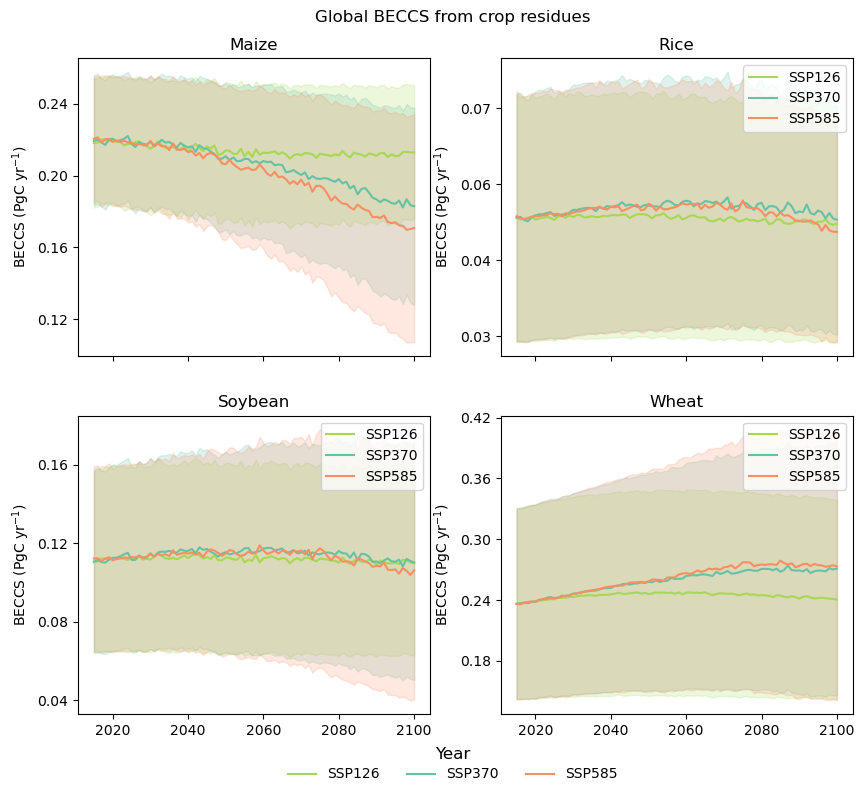

In [ ]:
## 3.1.1.1 time series

BE_ssp126 = xr.load_dataarray(f'results/Oct/ISIMIP3b/BECCS_ssp126.nc')
BE_ssp126 = BE_ssp126.mean(['gcm', 'data_Ac', 'data_Ah']).to_dataframe().reset_index()
BE_ssp370 = xr.load_dataarray(f'results/Oct/ISIMIP3b/BECCS_ssp370.nc')
BE_ssp370 = BE_ssp370.mean(['gcm', 'data_Ac', 'data_Ah']).to_dataframe().reset_index()
BE_ssp585 = xr.load_dataarray(f'results/Oct/ISIMIP3b/BECCS_ssp585.nc')
BE_ssp585 = BE_ssp585.mean(['gcm', 'data_Ac', 'data_Ah']).to_dataframe().reset_index()

errorbar = ('sd', 1)
fig, axes = plt.subplots(2, 2, figsize=(10, 8), **{'sharex': True, 'sharey': False})

handles = []
labels = []
for spc in spcs4:
    spc_type = next((key for key, value in crop_mapping.items() if spc in value), None)
    if spc_type is None: raise ValueError(f'Crop species {spc} not found in crop mapping.')
    ax = axes.flatten()[spcs4.index(spc)]
    sns.lineplot(data=BE_ssp126[BE_ssp126['spc_crop'] == spc], x='year', y='BE', label='SSP126', color=scen_colors[1], errorbar=errorbar, ax=ax)
    sns.lineplot(data=BE_ssp370[BE_ssp370['spc_crop'] == spc], x='year', y='BE', label='SSP370', color=scen_colors[2], errorbar=errorbar, ax=ax)
    sns.lineplot(data=BE_ssp585[BE_ssp585['spc_crop'] == spc], x='year', y='BE', label='SSP585', color=scen_colors[3], errorbar=errorbar, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('BECCS (PgC yr$^{-1}$)')
    ax.set_title(rf'{spc_type}')
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
    if spcs4.index(spc) == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend().remove()

fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
fig.suptitle(r'Global BECCS from crop residues')
fig.supxlabel('Year', x=0.5, y=0.04)
plt.subplots_adjust(top=0.92, bottom=0.1)

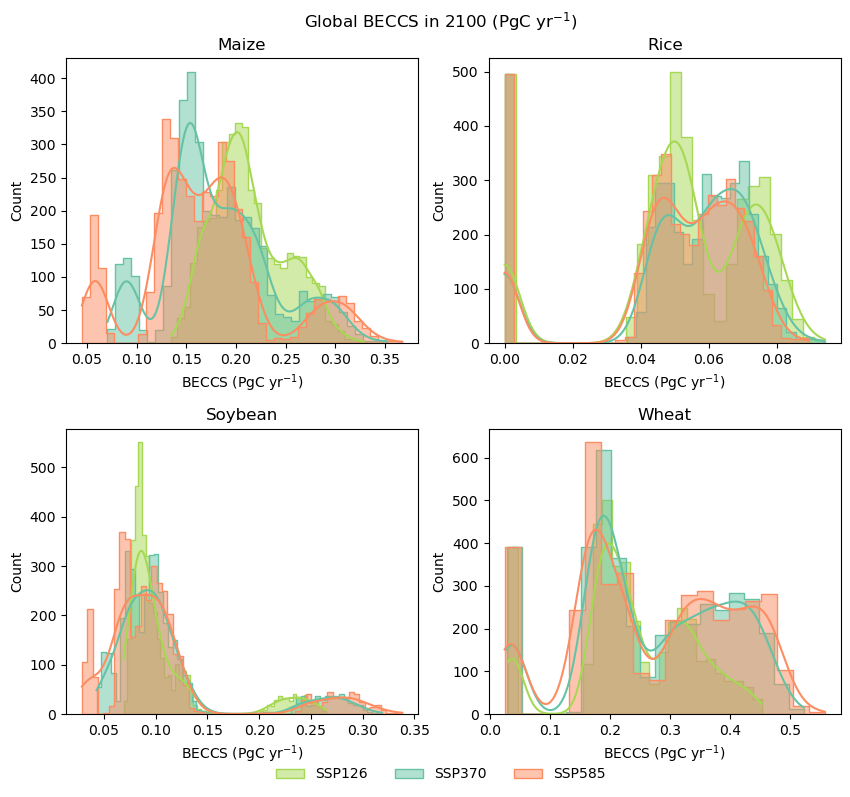

In [ ]:
## 3.1.1.2 distribution

BE_ssp126 = xr.load_dataarray(f'results/Oct/ISIMIP3b/BECCS_ssp126.nc').sel(year=2100, drop=True)
BE_ssp126 = BE_ssp126.mean(['gcm', 'data_Ac', 'data_Ah']).to_dataframe().reset_index()
BE_ssp370 = xr.load_dataarray(f'results/Oct/ISIMIP3b/BECCS_ssp370.nc').sel(year=2100, drop=True)
BE_ssp370 = BE_ssp370.mean(['gcm', 'data_Ac', 'data_Ah']).to_dataframe().reset_index()
BE_ssp585 = xr.load_dataarray(f'results/Oct/ISIMIP3b/BECCS_ssp585.nc').sel(year=2100, drop=True)
BE_ssp585 = BE_ssp585.mean(['gcm', 'data_Ac', 'data_Ah']).to_dataframe().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(10, 8), **{'sharex': False, 'sharey': False})

handles = []
labels = []
for spc in spcs4:
    spc_type = next((key for key, value in crop_mapping.items() if spc in value), None)
    if spc_type is None: raise ValueError(f'Crop species {spc} not found in crop mapping.')
    ax = axes.flatten()[spcs4.index(spc)]
    ax.set_title(rf'{spc_type}')
    sns.histplot(data=BE_ssp126[BE_ssp126['spc_crop'] == spc], x='BE', label='SSP126', alpha=0.5, kde=True, element='step', color=scen_colors[1], ax=ax)
    sns.histplot(data=BE_ssp370[BE_ssp370['spc_crop'] == spc], x='BE', label='SSP370', alpha=0.5, kde=True, element='step', color=scen_colors[2], ax=ax)
    sns.histplot(data=BE_ssp585[BE_ssp585['spc_crop'] == spc], x='BE', label='SSP585', alpha=0.5, kde=True, element='step', color=scen_colors[3], ax=ax)
    ax.set_xlabel(r'BECCS (PgC yr$^{-1}$)')
    if spcs4.index(spc) == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend().remove()

fig.suptitle(r'Global BECCS in 2100 (PgC yr$^{-1}$)')
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
plt.subplots_adjust(top=0.92, bottom=0.1, hspace=0.3)

#### 3.1.2 Sensitivity

++++++++++++++++++++++++++++++++++++++++++++++++++
Current date and time: 2026-03-25 10:02:16.470372
++++++++++++++++++++++++++++++++++++++++++++++++++ 

<xarray.Dataset> Size: 168B
Dimensions:   (spc_crop: 6)
Coordinates:
  * spc_crop  (spc_crop) <U3 72B 'mai' 'ri1' 'ri2' 'soy' 'swh' 'wwh'
Data variables:
    SC        (spc_crop) float64 48B 0.001215 0.001215 ... 0.001215 0.001215
    ST        (spc_crop) float64 48B -0.1174 -0.1174 -0.1174 ... -0.1174 -0.1174


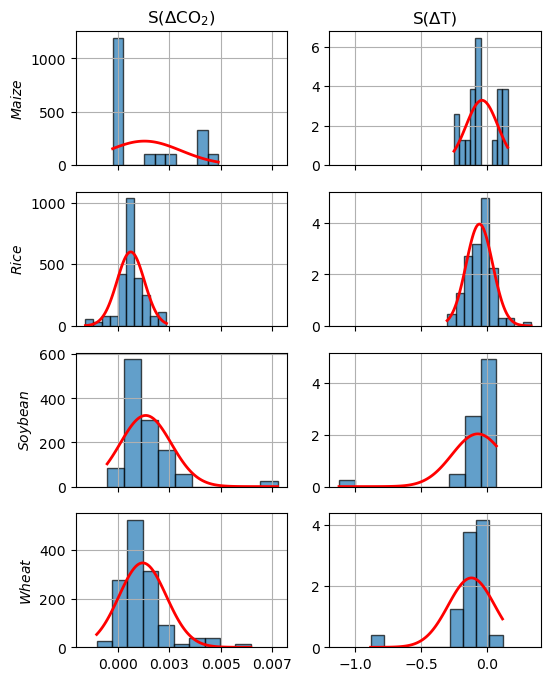

In [3]:
## 3.1.2.1 deal with experiment data

print('+'*50)
current_datetime = datetime.now()
print(f'Current date and time: {current_datetime}')
print('+'*50, '\n')

dir = '/h/u145/liuxinrui/Data/'

sens = xr.Dataset()
sens.coords['spc_crop'] = spcs
sens['SC'] = xr.DataArray(np.nan * np.zeros(len(spcs)), dims=['spc_crop'], coords={'spc_crop': spcs})
sens['SC'].attrs['long_name'] = 'Sensitivity of yield to CO2'
sens['ST'] = xr.DataArray(np.nan * np.zeros(len(spcs)), dims=['spc_crop'], coords={'spc_crop': spcs})
sens['ST'].attrs['long_name'] = 'Sensitivity of yield to temperature'

fig, axes = plt.subplots(4, 2, figsize=(6, 8))
for s, crop in enumerate(crop_mapping.keys()):
    xlsx = os.path.join(dir, 'Experiment', f'{crop}_Yield.xlsx')
    df = pd.read_excel(xlsx, sheet_name='Database', header=0, index_col=[0])
    data_sc = df['S(ΔCO2)'].dropna()
    mu_sc, std_sc = norm.fit(data_sc)
    x_sc = np.linspace(data_sc.min(), data_sc.max(), 100)
    p_sc = norm.pdf(x_sc, mu_sc, std_sc)
    data_st = df['S(ΔT)'].dropna()
    mu_st, std_st = norm.fit(data_st)
    x_st = np.linspace(data_st.min(), data_st.max(), 100)
    p_st = norm.pdf(x_st, mu_st, std_st)

    ax_sc = axes[s, 0]
    ax_sc.hist(data_sc, bins=10, edgecolor='black', alpha=0.7, density=True)
    ax_sc.plot(x_sc, p_sc, 'r-', linewidth=2)
    ax_sc.set_ylabel(rf'$\it{{{crop}}}$')
    ax_sc.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    ax_sc.grid(True)

    ax_st = axes[s, 1]
    ax_st.hist(data_st, bins=10, edgecolor='black', alpha=0.7, density=True)
    ax_st.plot(x_st, p_st, 'r-', linewidth=2)
    ax_st.grid(True)

    if s == 0:
        ax_sc.set_title(rf'S(ΔCO$_2$)')
        ax_st.set_title(rf'S(ΔT)')
    if s < 3:
        ax_sc.set_xlabel('')
        ax_sc.tick_params(labelbottom=False)
        ax_st.set_xlabel('')
        ax_st.tick_params(labelbottom=False)
    if s > 0:
        ax_sc.sharex(axes[0, 0])
        ax_st.sharex(axes[0, 1])

    for i, spc in enumerate(spcs):
        sens['SC'].loc[{'spc_crop': spc}] = data_sc.mean()
        sens['SC'].attrs['std'] = data_sc.std()
        sens['ST'].loc[{'spc_crop': spc}] = data_st.mean()
        sens['ST'].attrs['std'] = data_st.std()
print(sens)
plt.show()

++++++++++++++++++++++++++++++++++++++++++++++++++
Current date and time: 2026-03-25 10:03:35.849320
++++++++++++++++++++++++++++++++++++++++++++++++++ 

mai	ΔCO2	Exp:  200	Sim:  199	2041–2060
mai	ΔT	Exp:  2.46	Sim:  2.49	2042–2061
ri1	ΔCO2	Exp:  210	Sim:  206	2042–2061
ri1	ΔT	Exp:  2.84	Sim:  2.86	2056–2075
ri2	ΔCO2	Exp:  210	Sim:  206	2042–2061
ri2	ΔT	Exp:  2.84	Sim:  2.84	2055–2074
soy	ΔCO2	Exp:  251	Sim:  254	2048–2067
soy	ΔT	Exp:  3.12	Sim:  3.13	2050–2069
swh	ΔCO2	Exp:  207	Sim:  206	2042–2061
swh	ΔT	Exp:  1.88	Sim:  1.87	2032–2051
wwh	ΔCO2	Exp:  207	Sim:  206	2042–2061
wwh	ΔT	Exp:  1.88	Sim:  1.86	2033–2052


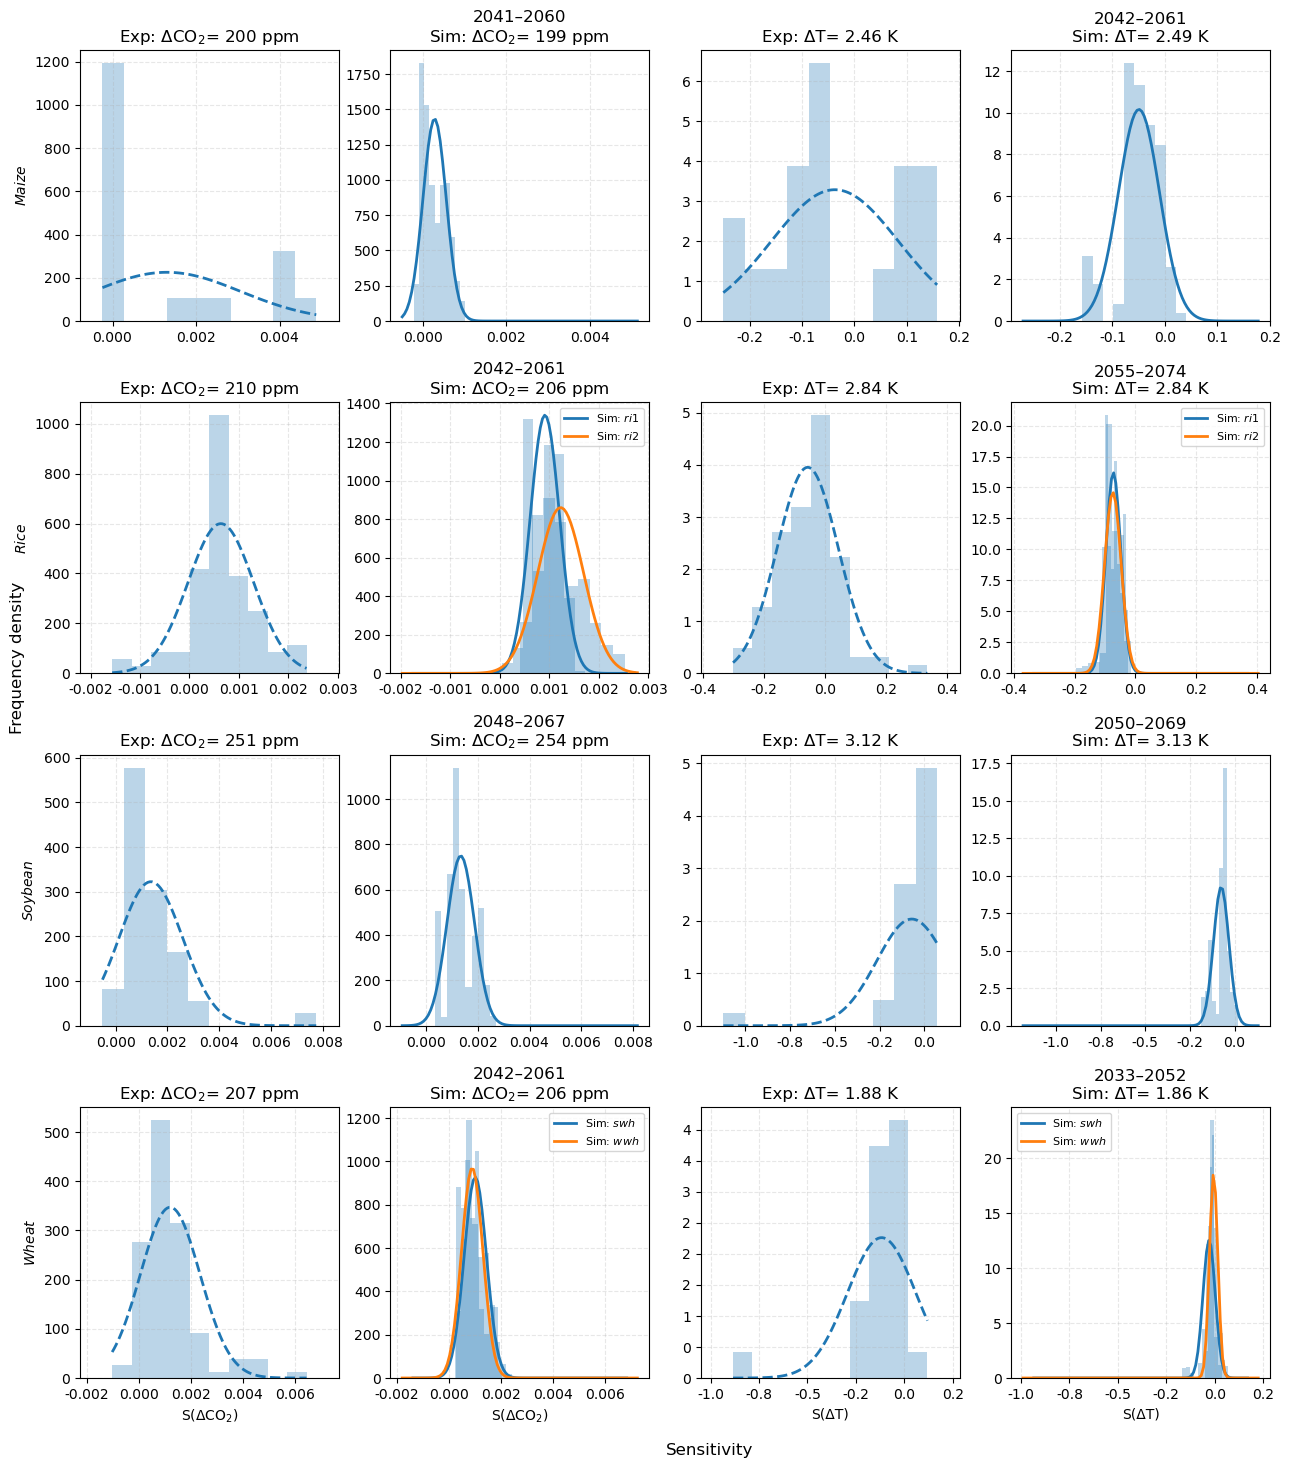

In [ ]:
## 3.1.2.2. generate output constraints

print('+'*50)
current_datetime = datetime.now()
print(f'Current date and time: {current_datetime}')
print('+'*50, '\n')

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab10.colors)
OUTPUT_CON = False

ind1 = (1991, 2010)
fig, axes = plt.subplots(len(crop_mapping), 2 * 2, figsize=(14, 4 * len(crop_mapping)))
weight = []
for s, crop in enumerate(crop_mapping.keys()):
    xlsx = os.path.join(dir, 'Experiment', f'{crop}_Yield.xlsx')
    df = pd.read_excel(xlsx, sheet_name='Database', header=0, index_col=[0])

    ax_sc_exp = axes[s, 0]
    ax_sc_sim = axes[s, 1]
    ax_sc_exp.sharex(ax_sc_sim)
    ax_st_exp = axes[s, 2]
    ax_st_sim = axes[s, 3]
    ax_st_exp.sharex(ax_st_sim)

    if 'S(ΔCO2)' in df.columns:
        data_sc = df[['ΔCO2', 'S(ΔCO2)']].dropna(subset=['S(ΔCO2)'])
        mu_sc, std_sc = norm.fit(data_sc['S(ΔCO2)'])
        x_sc = np.linspace(data_sc['S(ΔCO2)'].min(), data_sc['S(ΔCO2)'].max(), 100)
        p_sc = norm.pdf(x_sc, mu_sc, std_sc)
        ax_sc_exp.hist(data_sc['S(ΔCO2)'], bins=10, alpha=0.3, density=True)
        ax_sc_exp.plot(x_sc, p_sc, c='tab:blue', ls='--', linewidth=2)
        ax_sc_exp.set_title(rf'Exp: ΔCO$_2$={data_sc['ΔCO2'].mean(): .0f} ppm')
        ax_sc_exp.set_xlabel(rf'S(ΔCO$_2$)')
        ax_sc_exp.set_ylabel(rf'$\it{{{crop}}}$')
        ax_sc_exp.grid(True, which='both', ls='--', alpha=0.3)
        ax_sc_exp.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
        ax_sc_exp.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    else:
        print(f'Warning: \'S(ΔCO2)\' column not found')
        ax_sc_exp.set_title(rf'{crop} - Exp S(ΔCO$_2$) - Not Found')

    if 'S(ΔT)' in df.columns:
        data_st = df[['ΔT', 'S(ΔT)']].dropna(subset=['S(ΔT)'])
        mu_st, std_st = norm.fit(data_st['S(ΔT)'])
        x_st = np.linspace(data_st['S(ΔT)'].min(), data_st['S(ΔT)'].max(), 100)
        p_st = norm.pdf(x_st, mu_st, std_st)
        ax_st_exp.hist(data_st['S(ΔT)'], bins=10, alpha=0.3, density=True)
        ax_st_exp.plot(x_st, p_st, c='tab:blue', ls='--', linewidth=2)
        ax_st_exp.set_title(rf'Exp: ΔT={data_st["ΔT"].mean(): .2f} K')
        ax_st_exp.set_xlabel(rf'S(ΔT)')
        ax_st_exp.grid(True, which='both', ls='--', alpha=0.3)
        ax_st_exp.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax_st_exp.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    else:
        print(f'Warning: \'S(ΔT)\' column not found')
        ax_st_exp.set_title(f'{crop} - Exp S(ΔT) - Not Found')

    # --- data storage in xarray ---
    for i, spc in enumerate(crop_mapping[crop]):
        if spc in spcs:
            if 'S(ΔCO2)' in df.columns:
                sens['SC'].loc[{'spc_crop': spc}] = data_sc['S(ΔCO2)'].mean()
                sens['SC'].attrs['std'] = data_sc['S(ΔCO2)'].std()
            else:
                sens['SC'].loc[{'spc_crop': spc}] = np.nan
            if 'S(ΔT)' in df.columns:
                sens['ST'].loc[{'spc_crop': spc}] = data_st['S(ΔT)'].mean()
                sens['ST'].attrs['std'] = data_st['S(ΔT)'].std()
            else:
                sens['ST'].loc[{'spc_crop': spc}] = np.nan

            con_avg_sc = sens['SC'].sel(spc_crop=spc)
            con_std_sc = sens['SC'].attrs['std']
            sc = CY.sel(spc_crop=spc) / RT.sel(spc_crop=spc) / RP.sel(spc_crop=spc)
            ind_opt_c = 2031
            co2_btw_opt = data_sc['ΔCO2'].mean() + (
                co2.sel(year=slice(*ind1)).mean('year') - co2.sel(year=slice(ind_opt_c, ind_opt_c+19)).mean('year')
                ).values
            for ind_s in np.arange(2031, 2081):
                d_co2 = co2.sel(year=slice(*ind1)).mean('year') - co2.sel(year=slice(ind_s, ind_s+19)).mean('year')
                co2_btw = data_sc['ΔCO2'].mean() + d_co2.mean().values
                if np.abs(co2_btw) < np.abs(co2_btw_opt): ind_opt_c = ind_s; co2_btw_opt = co2_btw
            d_co2 = co2.sel(year=slice(ind_opt_c, ind_opt_c+19)).mean('year') - co2.sel(year=slice(*ind1)).mean('year')
            con_val_sc = (sc.sel(year=slice(ind_opt_c, ind_opt_c+19)).mean('year') / sc.sel(year=slice(*ind1)).mean('year') - 1) / d_co2
            wc = (1 / con_std_sc / np.sqrt(2 * np.pi) * np.exp(-0.5 * (con_val_sc - con_avg_sc) ** 2 / con_std_sc ** 2))
            wc.name = 'Wc'
            print(f'{spc}\tΔCO2\tExp: {data_sc['ΔCO2'].mean(): .0f}\tSim: {d_co2.values: .0f}\t{ind_opt_c:d}–{ind_opt_c+19:d}')

            con_avg_st = sens['ST'].sel(spc_crop=spc)
            con_std_st = sens['ST'].attrs['std']
            st = CY.sel(spc_crop=spc) / RC.sel(spc_crop=spc) / RP.sel(spc_crop=spc)
            ind_opt_t = 2031
            tgs_btw_opt = data_st['ΔT'].mean() + (
                D_Tgs.sel(spc_crop=spc, year=slice(*ind1)).mean('year') - D_Tgs.sel(spc_crop=spc, year=slice(ind_opt_t, ind_opt_t+19)).mean('year')
                ).mean().values
            for ind_s in np.arange(2031, 2081):
                d_tgs = D_Tgs.sel(spc_crop=spc, year=slice(*ind1)).mean('year') - D_Tgs.sel(spc_crop=spc, year=slice(ind_s, ind_s+19)).mean('year')
                tgs_btw = data_st['ΔT'].mean() + d_tgs.mean().values
                if np.abs(tgs_btw) < np.abs(tgs_btw_opt): ind_opt_t = ind_s; tgs_btw_opt = tgs_btw
            d_tgs = D_Tgs.sel(spc_crop=spc, year=slice(ind_opt_t, ind_opt_t+19)).mean('year') - D_Tgs.sel(spc_crop=spc, year=slice(*ind1)).mean('year')
            con_val_st = (st.sel(year=slice(ind_opt_t, ind_opt_t+19)).mean('year') / st.sel(year=slice(*ind1)).mean('year') - 1) / d_tgs
            wt = (1 / con_std_st / np.sqrt(2 * np.pi) * np.exp(-0.5 * (con_val_st - con_avg_st) ** 2 / con_std_st ** 2))
            wt.name = 'Wt'
            print(f'{spc}\tΔT\tExp: {data_st['ΔT'].mean(): .2f}\tSim: {d_tgs.mean().values: .2f}\t{ind_opt_t:d}–{ind_opt_t+19:d}')
            
            weight.append(wc.fillna(0).assign_coords(spc_crop=spc).expand_dims('spc_crop'))
            weight.append(wt.fillna(0).assign_coords(spc_crop=spc).expand_dims('spc_crop'))

            # --- plotting simulated data ---
            df_sc_sim = con_val_sc.to_dataframe('RC').dropna(subset=['RC'])
            mu_sc, std_sc = norm.fit(df_sc_sim['RC'])
            x_sc = np.linspace(*ax_sc_sim.get_xlim(), 100)
            p_sc = norm.pdf(x_sc, mu_sc, std_sc)
            ax_sc_sim.plot(x_sc, p_sc, linewidth=2, label=rf'Sim: $\it{{{spc}}}$')
            color = ax_sc_sim.get_lines()[0].get_color()
            ax_sc_sim.hist(df_sc_sim['RC'], bins=10, alpha=0.3, density=True, color=color)
            ax_sc_sim.set_title(
                f'{ind_opt_c:d}–{ind_opt_c+19:d}\n'
                rf'Sim: ΔCO$_2$={d_co2.mean().values: .0f} ppm'
            )
            ax_sc_sim.set_xlabel(rf'S(ΔCO$_2$)')
            ax_sc_sim.grid(True, which='both', ls='--', alpha=0.3)
            ax_sc_sim.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

            df_st_sim = con_val_st.to_dataframe('RT').dropna(subset=['RT'])
            mu_st, std_st = norm.fit(df_st_sim['RT'])
            x_st = np.linspace(*ax_st_sim.get_xlim(), 100)
            p_st = norm.pdf(x_st, mu_st, std_st)
            ax_st_sim.plot(x_st, p_st, linewidth=2, label=rf'Sim: $\it{{{spc}}}$')
            color = ax_st_sim.get_lines()[0].get_color()
            ax_st_sim.hist(df_st_sim['RT'], bins=10, alpha=0.3, density=True, color=color)
            ax_st_sim.set_title(
                f'{ind_opt_t:d}–{ind_opt_t+19:d}\n'
                f'Sim: ΔT={d_tgs.mean().values: .2f} K'
            )
            ax_st_sim.set_xlabel('S(ΔT)')
            ax_st_sim.grid(True, which='both', ls='--', alpha=0.3)
            ax_st_sim.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

            if crop in ['Rice', 'Wheat']:
                ax_sc_sim.legend(fontsize=8)
                ax_st_sim.legend(fontsize=8)
            if s != 0:
                ax_sc_sim.set_ylabel('')
                ax_st_exp.set_ylabel('')
                ax_st_sim.set_ylabel('')
            if s != 3:
                ax_sc_exp.set_xlabel('')
                ax_sc_sim.set_xlabel('')
                ax_st_exp.set_xlabel('')
                ax_st_sim.set_xlabel('')

fig.supxlabel('Sensitivity', y=0.0, va='bottom')
fig.supylabel('Frequency density', x=0.0, ha='left')
plt.subplots_adjust(bottom=0.05, left=0.05, hspace=0.3, wspace=0.2)
plt.show()

weight = xr.merge(weight)
if OUTPUT_CON:
    weight = weight.fillna(0)
    weight.to_netcdf('results/constraints.nc')

++++++++++++++++++++++++++++++++++++++++++++++++++
Current date and time: 2026-03-25 10:10:54.312869
++++++++++++++++++++++++++++++++++++++++++++++++++ 

mai	ΔCO2	Exp:  200	Sim:  199	2041–2060
mai	S(ΔCO2)	Exp:  0.00130	Sim:  0.00028
mai	ΔT	Exp:  2.46	Sim:  2.49	2042–2061
mai	S(ΔT)	Exp: -0.04	Sim: -0.05
ri1	ΔCO2	Exp:  210	Sim:  206	2042–2061
ri1	S(ΔCO2)	Exp:  0.00064	Sim:  0.00091
ri1	ΔT	Exp:  2.84	Sim:  2.86	2056–2075
ri1	S(ΔT)	Exp: -0.06	Sim: -0.07
ri2	ΔCO2	Exp:  210	Sim:  206	2042–2061
ri2	S(ΔCO2)	Exp:  0.00064	Sim:  0.00123
ri2	ΔT	Exp:  2.84	Sim:  2.84	2055–2074
ri2	S(ΔT)	Exp: -0.06	Sim: -0.07
soy	ΔCO2	Exp:  251	Sim:  254	2048–2067
soy	S(ΔCO2)	Exp:  0.00136	Sim:  0.00134
soy	ΔT	Exp:  3.12	Sim:  3.13	2050–2069
soy	S(ΔT)	Exp: -0.07	Sim: -0.08
swh	ΔCO2	Exp:  207	Sim:  206	2042–2061
swh	S(ΔCO2)	Exp:  0.00122	Sim:  0.00101
swh	ΔT	Exp:  1.88	Sim:  1.87	2032–2051
swh	S(ΔT)	Exp: -0.12	Sim: -0.03
wwh	ΔCO2	Exp:  207	Sim:  206	2042–2061
wwh	S(ΔCO2)	Exp:  0.00122	Sim:  0.00089
wwh	ΔT	Exp:  1.88

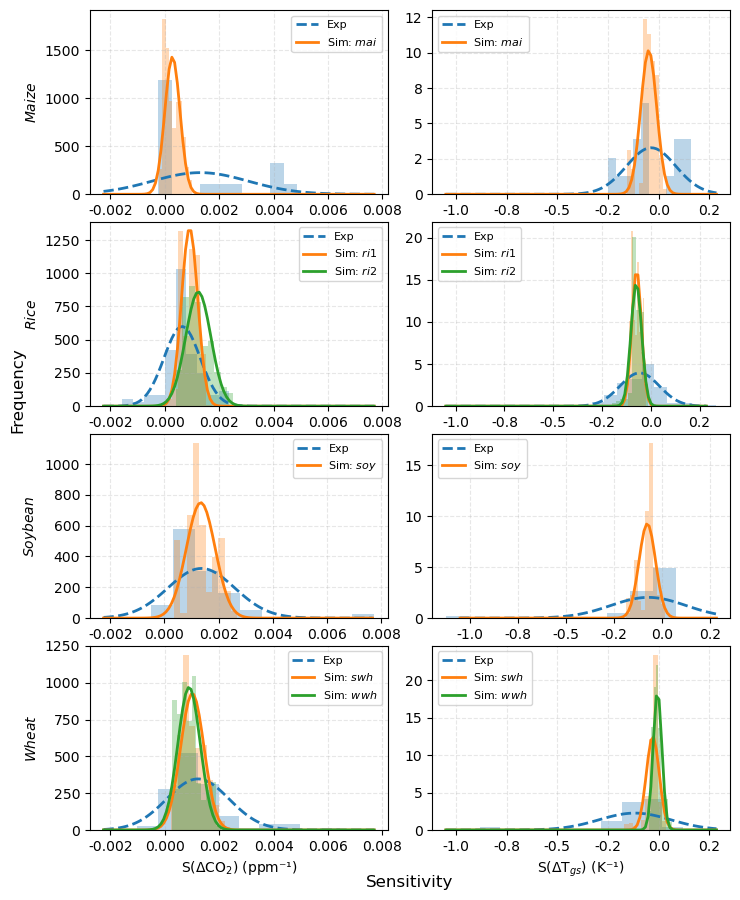

In [9]:
## 3.1.2.3. compare sensitivities

print('+'*50)
current_datetime = datetime.now()
print(f'Current date and time: {current_datetime}')
print('+'*50, '\n')

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab10.colors)
OUTPUT_CON = True

ind1 = (1991, 2010)
fig, axes = plt.subplots(len(crop_mapping), 2 , figsize=(8, 2.5 * len(crop_mapping)))
weight = []
for s, crop in enumerate(crop_mapping.keys()):
    xlsx = os.path.join(dir, 'Experiment', f'{crop}_Yield.xlsx')
    df = pd.read_excel(xlsx, sheet_name='Database', header=0, index_col=[0])

    ax_sc = axes[s, 0]
    ax_st = axes[s, 1]

    if 'S(ΔCO2)' in df.columns:
        data_sc = df[['ΔCO2', 'S(ΔCO2)']].dropna(subset=['S(ΔCO2)'])
        mu_sc, std_sc = norm.fit(data_sc['S(ΔCO2)'])
        x_sc = np.linspace(*ax_sc_sim.get_xlim(), 100)
        p_sc = norm.pdf(x_sc, mu_sc, std_sc)
        ax_sc.hist(data_sc['S(ΔCO2)'], bins=10, alpha=0.3, density=True)
        ax_sc.plot(x_sc, p_sc, 'tab:blue', ls='--', linewidth=2, label='Exp')
        ax_sc.set_xlabel(rf'S(ΔCO$_2$) (ppm⁻¹)')
        ax_sc.set_ylabel(rf'$\it{{{crop}}}$')
        ax_sc.grid(True, which='both', ls='--', alpha=0.3)
        ax_sc.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
        ax_sc.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    else:
        print(f'Warning: \'S(ΔCO2)\' column not found')
        ax_sc_exp.set_title(rf'{crop} - Exp S(ΔCO$_2$) - Not Found')

    if 'S(ΔT)' in df.columns:
        data_st = df[['ΔT', 'S(ΔT)']].dropna(subset=['S(ΔT)'])
        mu_st, std_st = norm.fit(data_st['S(ΔT)'])
        x_st = np.linspace(*ax_st_sim.get_xlim(), 100)
        p_st = norm.pdf(x_st, mu_st, std_st)
        ax_st.hist(data_st['S(ΔT)'], bins=10, alpha=0.3, density=True)
        ax_st.plot(x_st, p_st, 'tab:blue', ls='--', linewidth=2, label='Exp')
        ax_st.set_xlabel('S(ΔT$_{gs}$) (K⁻¹)')
        ax_st.grid(True, which='both', ls='--', alpha=0.3)
        ax_st.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        ax_st.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    else:
        print(f'Warning: \'S(ΔT)\' column not found')
        ax_st.set_title(f'{crop} - Exp S(ΔT) - Not Found')

    # --- Data Storage in xarray ---
    for i, spc in enumerate(crop_mapping[crop]):
        if spc in spcs:
            if 'S(ΔCO2)' in df.columns:
                sens['SC'].loc[{'spc_crop': spc}] = data_sc['S(ΔCO2)'].mean()
                sens['SC'].attrs['std'] = data_sc['S(ΔCO2)'].std()
            else:
                sens['SC'].loc[{'spc_crop': spc}] = np.nan
            if 'S(ΔT)' in df.columns:
                sens['ST'].loc[{'spc_crop': spc}] = data_st['S(ΔT)'].mean()
                sens['ST'].attrs['std'] = data_st['S(ΔT)'].std()
            else:
                sens['ST'].loc[{'spc_crop': spc}] = np.nan

            con_avg_sc = sens['SC'].sel(spc_crop=spc)
            con_std_sc = sens['SC'].attrs['std']
            sc = CY.sel(spc_crop=spc) / RT.sel(spc_crop=spc) / RP.sel(spc_crop=spc)
            ind_opt_c = 2031
            co2_btw_opt = data_sc['ΔCO2'].mean() + (
                co2.sel(year=slice(*ind1)).mean('year') - co2.sel(year=slice(ind_opt_c, ind_opt_c+19)).mean('year')
                ).values
            for ind_s in np.arange(2031, 2081):
                d_co2 = co2.sel(year=slice(*ind1)).mean('year') - co2.sel(year=slice(ind_s, ind_s+19)).mean('year')
                co2_btw = data_sc['ΔCO2'].mean() + d_co2.mean().values
                if np.abs(co2_btw) < np.abs(co2_btw_opt): ind_opt_c = ind_s; co2_btw_opt = co2_btw
            d_co2 = co2.sel(year=slice(ind_opt_c, ind_opt_c+19)).mean('year') - co2.sel(year=slice(*ind1)).mean('year')
            con_val_sc = (sc.sel(year=slice(ind_opt_c, ind_opt_c+19)).mean('year') / sc.sel(year=slice(*ind1)).mean('year') - 1) / d_co2

            con_avg_st = sens['ST'].sel(spc_crop=spc)
            con_std_st = sens['ST'].attrs['std']
            st = CY.sel(spc_crop=spc) / RC.sel(spc_crop=spc) / RP.sel(spc_crop=spc)
            ind_opt_t = 2031
            tgs_btw_opt = data_st['ΔT'].mean() + (
                D_Tgs.sel(spc_crop=spc, year=slice(*ind1)).mean('year') - D_Tgs.sel(spc_crop=spc, year=slice(ind_opt_t, ind_opt_t+19)).mean('year')
                ).mean().values
            for ind_s in np.arange(2031, 2081):
                d_tgs = D_Tgs.sel(spc_crop=spc, year=slice(*ind1)).mean('year') - D_Tgs.sel(spc_crop=spc, year=slice(ind_s, ind_s+19)).mean('year')
                tgs_btw = data_st['ΔT'].mean() + d_tgs.mean().values
                if np.abs(tgs_btw) < np.abs(tgs_btw_opt): ind_opt_t = ind_s; tgs_btw_opt = tgs_btw
            d_tgs = D_Tgs.sel(spc_crop=spc, year=slice(ind_opt_t, ind_opt_t+19)).mean('year') - D_Tgs.sel(spc_crop=spc, year=slice(*ind1)).mean('year')
            con_val_st = (st.sel(year=slice(ind_opt_t, ind_opt_t+19)).mean('year') / st.sel(year=slice(*ind1)).mean('year') - 1) / d_tgs
            
            # --- plotting simulated data ---
            df_sc_sim = con_val_sc.to_dataframe('RC').dropna(subset=['RC'])
            mu_sc, std_sc = norm.fit(df_sc_sim['RC'])
            x_sc = np.linspace(*ax_sc_sim.get_xlim(), 100)
            p_sc = norm.pdf(x_sc, mu_sc, std_sc)
            ax_sc.plot(x_sc, p_sc, linewidth=2, label=rf'Sim: $\it{{{spc}}}$')
            color = ax_sc.get_lines()[-1].get_color()
            ax_sc.hist(df_sc_sim['RC'], bins=10, alpha=0.3, density=True, color=color)

            df_st_sim = con_val_st.to_dataframe('RT').dropna(subset=['RT'])
            mu_st, std_st = norm.fit(df_st_sim['RT'])
            x_st = np.linspace(*ax_st_sim.get_xlim(), 100)
            p_st = norm.pdf(x_st, mu_st, std_st)
            ax_st.plot(x_st, p_st, linewidth=2, label=rf'Sim: $\it{{{spc}}}$')
            color = ax_st.get_lines()[-1].get_color()
            ax_st.hist(df_st_sim['RT'], bins=10, alpha=0.3, density=True, color=color)

            print(f'{spc}\tΔCO2\tExp: {data_sc['ΔCO2'].mean(): .0f}\tSim: {d_co2.values: .0f}\t{ind_opt_c:d}–{ind_opt_c+19:d}')
            print(f'{spc}\tS(ΔCO2)\tExp: {data_sc['S(ΔCO2)'].mean(): .5f}\tSim: {df_sc_sim['RC'].mean(): .5f}')
            print(f'{spc}\tΔT\tExp: {data_st['ΔT'].mean(): .2f}\tSim: {d_tgs.mean().values: .2f}\t{ind_opt_t:d}–{ind_opt_t+19:d}')
            print(f'{spc}\tS(ΔT)\tExp: {data_st['S(ΔT)'].mean(): .2f}\tSim: {df_st_sim['RT'].mean(): .2f}')

            ax_sc.legend(fontsize=8, loc='upper right')
            ax_st.legend(fontsize=8, loc='upper left')
            if s != 3:
                ax_sc.set_xlabel('')
                ax_st.set_xlabel('')

plt.subplots_adjust(bottom=0.06, left=0.1, hspace=0.15, wspace=0.15)
fig.supxlabel('Sensitivity', y=0.0, va='bottom')
fig.supylabel('Frequency', x=0.0, ha='left')
plt.show()

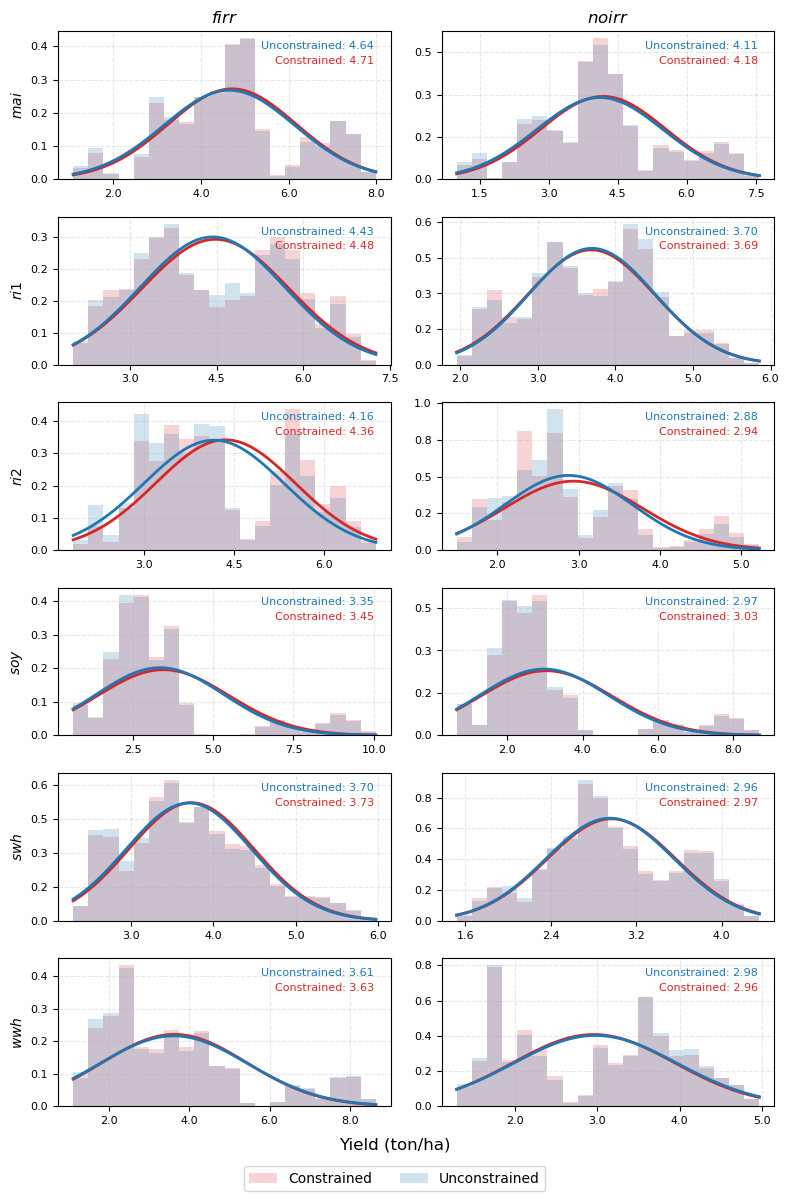

In [ ]:
## 3.1.2.4. plot the distribution

print('+'*50)
current_datetime = datetime.now()
print(f'Current date and time: {current_datetime}')
print('+'*50, '\n')

fig, axes = plt.subplots(6, 2, figsize=(8, 12))

PLOT_TYPE = 'hist'
yd = YD.sel(year=slice(2069, 2099)).mean('year').rename({'gcm': 'mod_clim_gcm'})
weight = xr.load_dataset(f'{out_dir}constraints.nc')
legend_handles = []
for s, spc in enumerate(spcs):
    for j, irr in enumerate(['firr', 'noirr']):
        ax = axes[s, j]
        ax.grid(True, which='both', ls='--', alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=8)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))
        ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: '{:.1f}'.format(x)))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
        
        yd_spc = yd.sel(spc_crop=spc, irr=irr).rename('Yield')
        w = ((weight['Wc'].sel(spc_crop=spc, irr=irr))*(weight['Wt'].sel(spc_crop=spc, irr=irr))).rename('Weight')
        yd_spc_con = yd_spc.weighted(w).mean()
        yd_spc_un = yd_spc.mean()
        df = xr.merge([yd_spc, w]).to_dataframe().dropna(subset=['Yield', 'Weight'])

        if PLOT_TYPE == 'kde':
            sns.kdeplot(
                data=df,
                x='Yield',
                weights='Weight',
                ax=ax,
                color='tab:red',
                label='Yield',
                fill=True,
                alpha=0.2
                )
            
            sns.kdeplot(
                data=df,
                x='Yield',
                ax=ax,
                color='tab:blue',
                label='Yield',
                fill=False,
                alpha=0.5
                )

        if PLOT_TYPE == 'hist':
            n, bins, patches = ax.hist(
                x='Yield',
                data=df,
                bins=20,
                weights=df['Weight'].values,
                density=True,
                alpha=0.2,
                color='tab:red',
                fill=True,
                lw=2,
                label='Constrained'
            )
            mu_w = np.average(df['Yield'], weights=df['Weight'])
            std_w = np.sqrt(np.average((df['Yield'] - mu_w)**2, weights=df['Weight']))
            x = np.linspace(bins.min(), bins.max(), 100)
            p = norm.pdf(x, mu_w, std_w)
            ax.plot(x, p, 'tab:red', linewidth=2)

            n, bins, patches = ax.hist(
                x='Yield',
                data=df,
                bins=20,
                density=True,
                alpha=0.2,
                color='tab:blue',
                lw=2,
                label='Unconstrained'
            )
            mu_u, std_u = norm.fit(df['Yield'])
            x = np.linspace(bins.min(), bins.max(), 100)
            p = norm.pdf(x, mu_u, std_u)
            ax.plot(x, p, 'tab:blue', linewidth=2)

        ax.text(
            0.95, 0.8, 
            f'Constrained: {yd_spc_con:.2f}', 
            transform=ax.transAxes,
            ha='right', 
            va='center', 
            color='tab:red',
            fontsize=8
        )

        ax.text(
            0.95, 0.9, 
            f'Unconstrained: {yd_spc_un:.2f}', 
            transform=ax.transAxes,
            ha='right', 
            va='center', 
            color='tab:blue',
            fontsize=8
        )
        
        if s == 0: ax.set_title(rf'$\it{{{irr}}}$')
        ax.set_xlabel('')
        if j == 0: 
            ax.set_ylabel(rf'$\it{{{spc}}}$')
        else:
            ax.set_ylabel('')
        
        if s == 0 and j == 0:
            handles, labels = ax.get_legend_handles_labels()
            legend_handles.extend(handles)
        
fig.supxlabel(r'Yield (ton/ha)', y=0.035)
fig.legend(legend_handles, ['Constrained', 'Unconstrained'], loc='lower center', ncol=4)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

## 3.2. Sub-national

++++++++++++++++++++++++++++++++++++++++++++++++++
Current date and time: 2026-03-25 10:12:58.315701
++++++++++++++++++++++++++++++++++++++++++++++++++ 



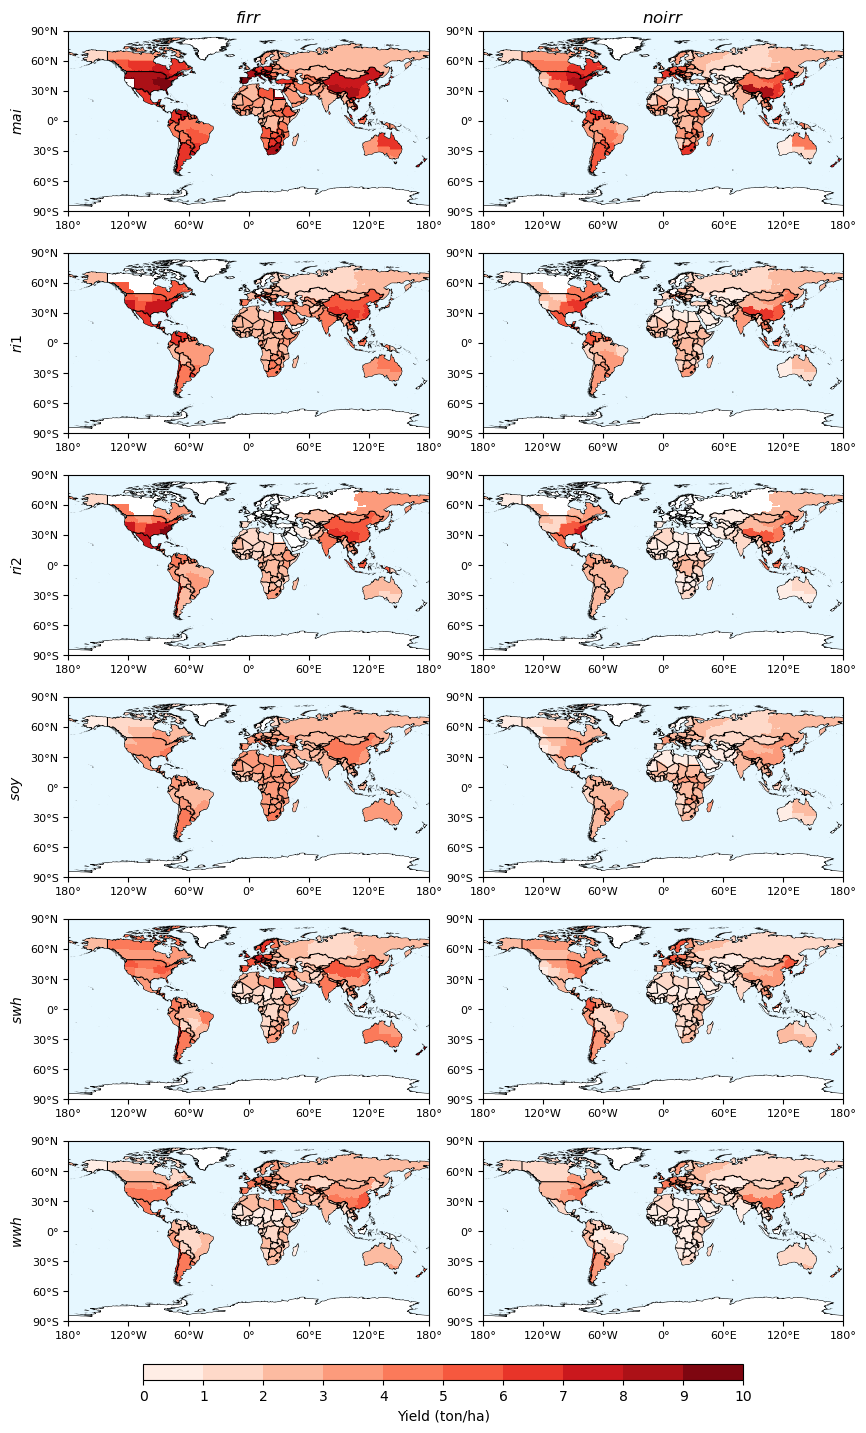

In [ ]:
## 3.2.1. plot global map

print('+'*50)
current_datetime = datetime.now()
print(f'Current date and time: {current_datetime}')
print('+'*50, '\n')

from core.utils_crop import create_global_map

CY = xr.load_dataarray(f'{out_dir}CY_ssp585.nc').mean(['config', 'gcm'])

fig, axes = plt.subplots(6, 2, figsize=(10, 16), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0.0)})
for j, irr in enumerate(['firr', 'noirr']):
    for i, spc in enumerate(spcs):
        try:
            ax = axes[i, j]
            if i == 0: ax.set_title(rf'$\it{{{irr}}}$')
            if j == 0: ax.set_ylabel(rf'$\it{{{spc}}}$')
            # Emulated yield
            yd_out = CY.sel(spc_crop=spc, irr=irr, year=slice(1981, 2010)).mean('year')
            ax, cf = create_global_map(yd_out, 
                        mask=map_mask, 
                        levels=np.linspace(0, 10, 11), 
                        ax=ax, 
                        cb_on=False, 
                        contourf_kwargs={'cmap': 'Reds'}, 
                        colorbar_kwargs={'extend': 'both', 'extendrect': False}
                    )
            ax.tick_params(axis='both', which='major', labelsize=8)
        except KeyError:
            ax0 = axes[i, 0]
            ax.tick_params(labelbottom=False, labelleft=False)
            ax.text(
                0.5, 0.5, 
                'No Data', 
                transform=ax.transAxes,
                ha='center', 
                va='center', 
                color='gray'
            )

fig.subplots_adjust(bottom=0.08, top=0.9, hspace=0.1, wspace=0.15)
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.01])
fig.colorbar(
    cf, cax=cbar_ax, label=rf'Yield (tDM ha$^{-1}$)', 
    orientation='horizontal', extend='both', ticks=np.linspace(0, 10, 11), extendrect=False
)
plt.show()